# 3 - Customer Segmentation Dashboard - Data Visualization

<img src='https://www.tidio.com/wp-content/uploads/Customer-segmentation-min.png'>

Bu çalışmada müşteri kişilik ve harcama verileri üzerinden segmentleri görselleştirerek müşteri davranışlarını farklı açılardan analiz edeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Temel istatistik ve ilişki analizi
6. Müşteri profili görselleştirme
7. Harcama davranışı görselleştirme
8. Kampanya ve segment görselleştirme
9. Sonuç


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Veriyi Yükleme

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Customer Personality Analysis.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config', 'drive', 'marketing_campaign.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde veri setini okuyup genel yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/marketing_campaign.csv', sep='	')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.shape


(2240, 29)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


## 3. Veri Temizleme

In [10]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df = df.drop(columns=['ID'])
df.head()


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0


## 4. Feature Engineering

In [11]:
# Bu bölümde yaş, toplam harcama ve toplam kampanya kabulü gibi analizde kullanacağım yeni sütunları oluşturacağım.

In [12]:
df['Year_Birth'] = pd.to_numeric(df['Year_Birth'], errors='coerce')
df['Age'] = 2026 - df['Year_Birth']
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['Total_Accepted_Campaigns'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df.head()


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Accepted_Campaigns
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,0,0,0,0,3,11,1,69,1617,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,0,0,0,0,3,11,0,72,27,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,0,0,0,0,3,11,0,61,776,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,0,0,0,0,3,11,0,42,53,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,0,0,0,0,3,11,0,45,422,0


## 5. Temel İstatistik ve İlişki Analizi

In [13]:
# Bu bölümde describe, korelasyon ve temel grafiklerle veri setindeki ilişkileri inceleyeceğim.

In [14]:
df[['Income','Age','Total_Spending','Total_Accepted_Campaigns']].describe()


,Income,Age,Total_Spending,Total_Accepted_Campaigns
count,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,57.194196,605.798214,0.446875
std,25037.955891,11.984069,602.249288,0.890543
min,1730.000000,30.000000,5.000000,0.000000
25%,35538.750000,49.000000,68.750000,0.000000
50%,51381.500000,56.000000,396.000000,0.000000
75%,68289.750000,67.000000,1045.500000,1.000000
max,666666.000000,133.000000,2525.000000,5.000000


In [15]:
corr_df = df[['Income','Age','Total_Spending','Total_Accepted_Campaigns']].corr(numeric_only=True)
corr_df


,Income,Age,Total_Spending,Total_Accepted_Campaigns
Income,1.000000,0.160899,0.664775,0.287109
Age,0.160899,1.000000,0.111306,-0.008302
Total_Spending,0.664775,0.111306,1.000000,0.456206
Total_Accepted_Campaigns,0.287109,-0.008302,0.456206,1.000000


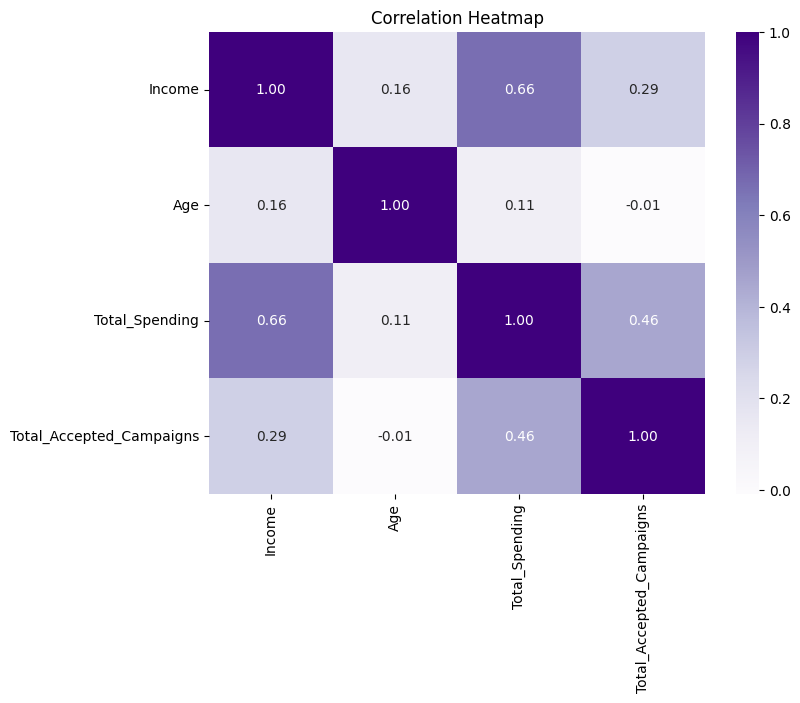

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='Purples', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


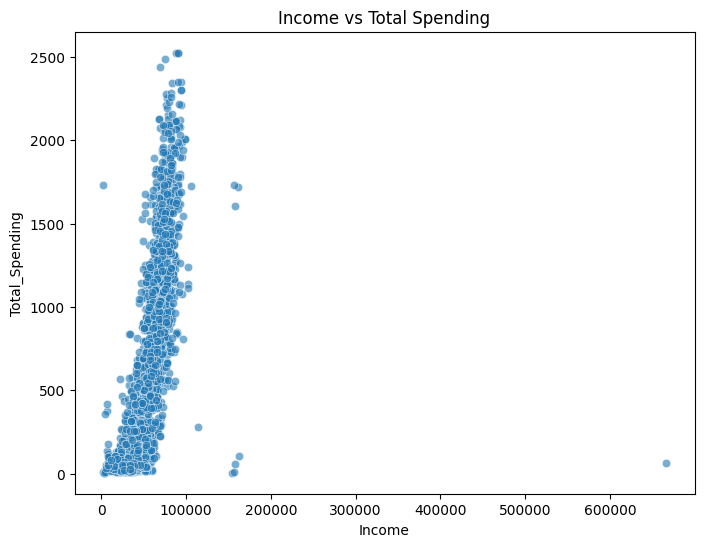

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Income', y='Total_Spending', alpha=0.6)
plt.title('Income vs Total Spending')
plt.show()


## 6. Müşteri Profili Görselleştirme

In [18]:
# Bu bölümde yaş ve eğitim gibi müşteri profil özelliklerini görselleştireceğim.

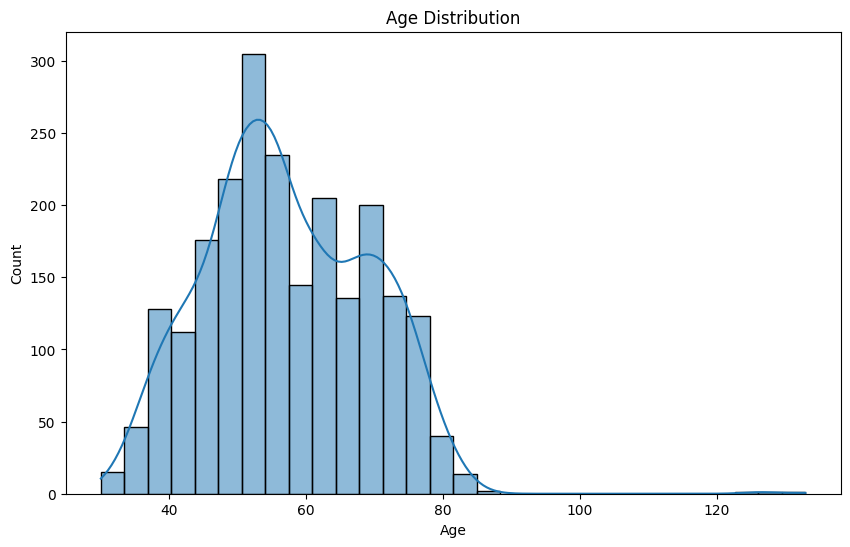

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()


In [20]:
education_counts = df['Education'].value_counts().reset_index()
education_counts.columns = ['Education', 'Count']
fig = px.pie(education_counts, names='Education', values='Count', title='Education Distribution')
fig.show()


## 7. Harcama Davranışı Görselleştirme

In [21]:
# Bu bölümde ürün gruplarına göre harcama dağılımını ve toplam harcama davranışını inceleyeceğim.

In [22]:
spending_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
spending_totals = df[spending_cols].sum().reset_index()
spending_totals.columns = ['Product', 'Amount']
fig = px.bar(spending_totals, x='Product', y='Amount', title='Total Spending by Product Category')
fig.show()


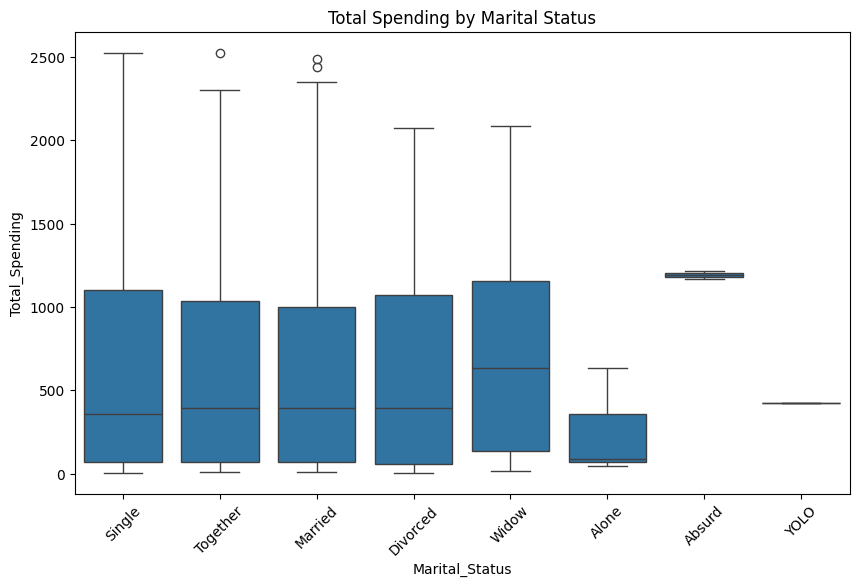

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Marital_Status', y='Total_Spending')
plt.xticks(rotation=45)
plt.title('Total Spending by Marital Status')
plt.show()


## 8. Kampanya ve Segment Görselleştirme

In [24]:
# Bu bölümde kampanya kabulü ve müşteri segment davranışlarını görselleştireceğim.

In [25]:
campaign_counts = df['Total_Accepted_Campaigns'].value_counts().sort_index().reset_index()
campaign_counts.columns = ['Campaign_Count', 'Customer_Count']
fig = px.bar(campaign_counts, x='Campaign_Count', y='Customer_Count', title='Accepted Campaign Distribution')
fig.show()


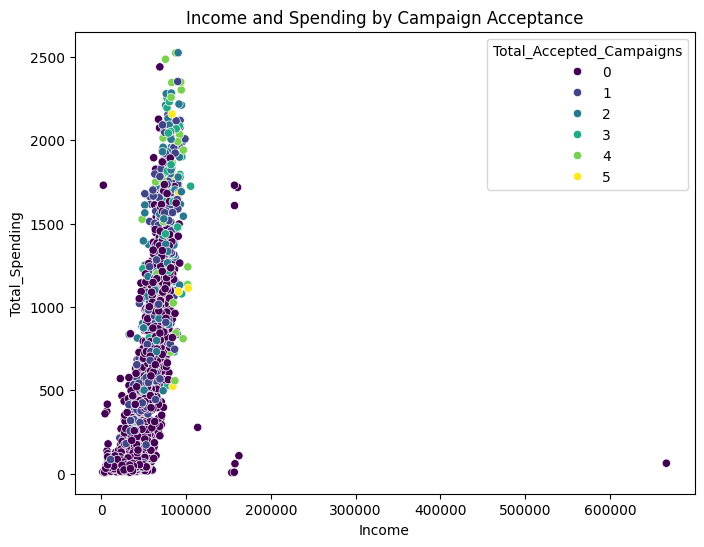

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Income', y='Total_Spending', hue='Total_Accepted_Campaigns', palette='viridis')
plt.title('Income and Spending by Campaign Acceptance')
plt.show()


## 9. Sonuç

Bu projede müşteri kişilik ve harcama verileri görselleştirme odaklı olarak analiz edildi. Elde edilen grafikler ile müşteri profili, harcama alışkanlıkları ve kampanya tepkileri anlaşılır şekilde ortaya kondu.